# Lab 2: Clustering

Author: Adam Jakubowski 193352

## 1. Visualize the Input Data

Dataset: s1
Shape: (5000, 2)
                   0              1
count    5000.000000    5000.000000
mean   514937.556600  494709.292800
std    244465.901926  235840.852969
min     19835.000000   51121.000000
25%    320352.500000  320107.750000
50%    505338.500000  526259.500000
75%    786228.750000  713713.500000
max    961951.000000  970756.000000 

Dataset: birch1
Shape: (100000, 2)
                   0              1
count  100000.000000   100000.00000
mean   495949.168300   495915.70070
std    265760.545078   265692.57357
min      1371.000000        0.00000
25%    265583.750000   265574.00000
50%    496023.000000   494984.50000
75%    726553.000000   726686.50000
max    996108.000000  1000000.00000 

Dataset: n1
Shape: (2250, 2)
                 0            1
count  2250.000000  2250.000000
mean   1287.528889  1235.433333
std     552.010266   311.483507
min     134.000000    87.000000
25%     808.000000  1044.000000
50%    1088.500000  1296.000000
75%    1901.000000  1444.000000

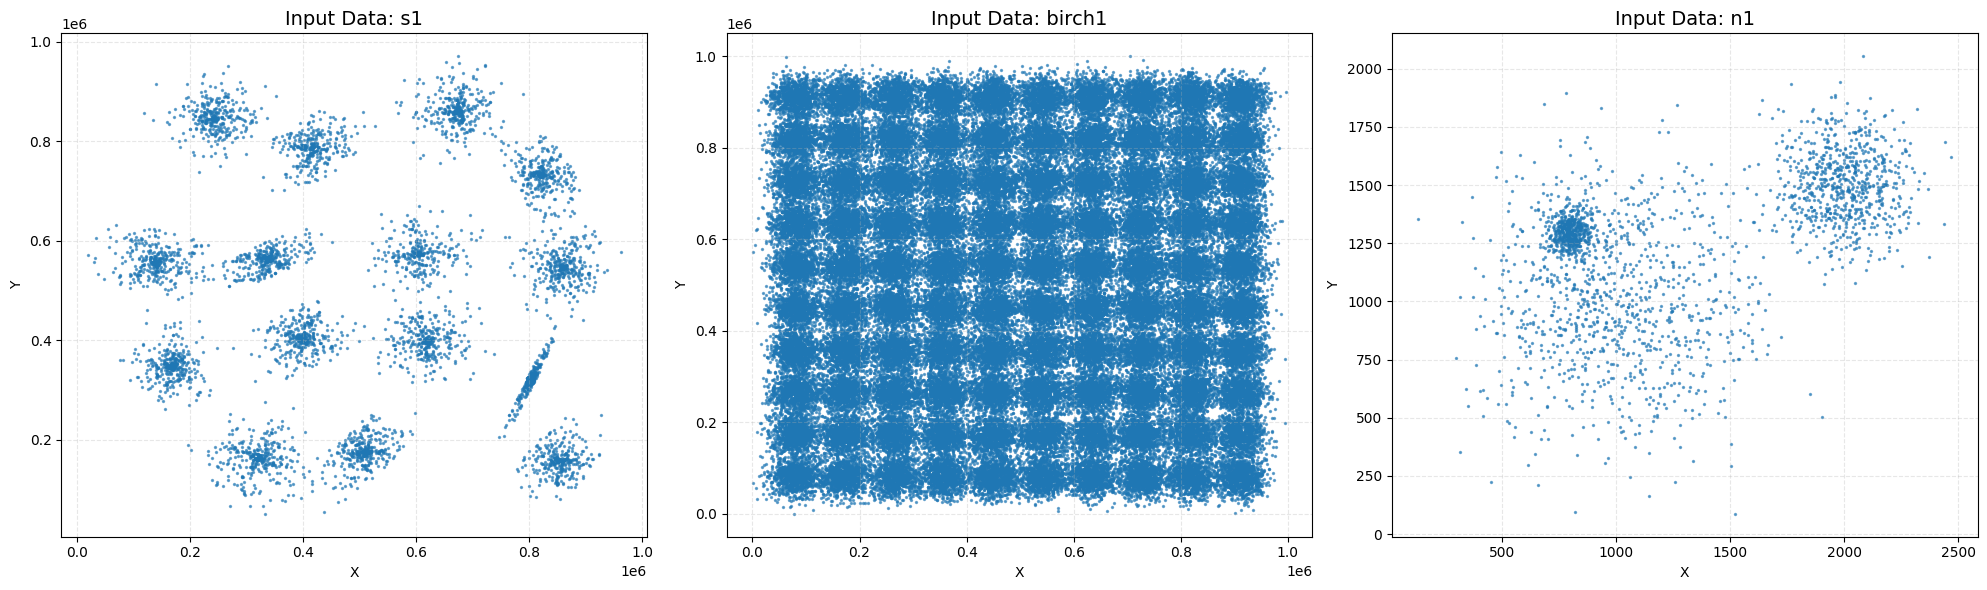

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

loaded_data = {}

datasets_paths = {
    's1': 'data/1_S-sets/s1.txt',
    'birch1': 'data/2_Birch-sets/birch1.txt',
    'n1': 'data/4_Nested-datasets/n1.txt'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, path) in enumerate(datasets_paths.items()):
    df = pd.read_csv(path, sep=r'\s+', header=None)
    loaded_data[name] = df
    
    axes[i].scatter(df[0], df[1], s=2, alpha=0.6, color='tab:blue')
    axes[i].set_title(f"Input Data: {name}", fontsize=14)
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].grid(True, linestyle='--', alpha=0.3)
    
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape}")
    print(df.describe(), "\n")

plt.tight_layout()
plt.show()

## 2. K-Means Clustering


--- Processing K-Means for S-sets (s1) data set ---
k=2, silhouette=0.3841
k=3, silhouette=0.4150
k=4, silhouette=0.4454
k=5, silhouette=0.4671
k=6, silhouette=0.4979
k=7, silhouette=0.5267
k=8, silhouette=0.5391
k=9, silhouette=0.5664
k=10, silhouette=0.6029
k=11, silhouette=0.6069
k=12, silhouette=0.6276
k=13, silhouette=0.6615
k=14, silhouette=0.6418
k=15, silhouette=0.6341
k=16, silhouette=0.6833
k=17, silhouette=0.6531
k=18, silhouette=0.6336
k=19, silhouette=0.6445
k=20, silhouette=0.5881

Optimal k for S-sets (s1) based on Silhouette: 16


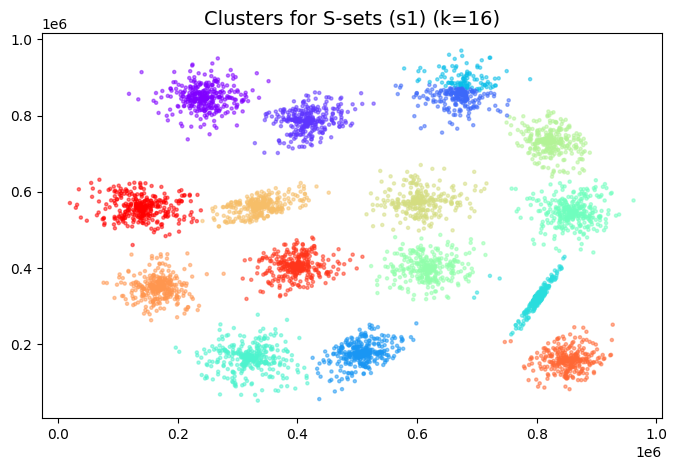


--- Processing K-Means for Nested-datasets (n1) data set ---
k=2, silhouette=0.5782
k=3, silhouette=0.5806
k=4, silhouette=0.5393
k=5, silhouette=0.4463

Optimal k for Nested-datasets (n1) based on Silhouette: 3


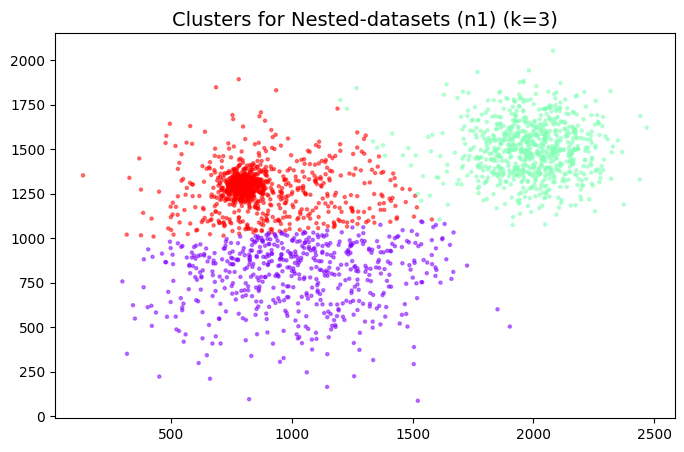

In [3]:
from sklearn.preprocessing import StandardScaler

def compute_kmeans(df, range, title=""):
    print(f"\n--- Processing K-Means for {title} data set ---")

    scores = []
    best_k = 2
    best_lables = None
    max_silhouette = -1

    my_scaler = StandardScaler()
    scaled_features = my_scaler.fit_transform(df)

    for k in range:
        k_means = KMeans(n_clusters=k, random_state=42, init='random', n_init='auto')
        k_means.fit(scaled_features)

        score = silhouette_score(scaled_features, k_means.labels_)
        scores.append(score)

        if score > max_silhouette:
            max_silhouette = score
            best_k = k
            best_lables = k_means.labels_


        print(f"k={k}, silhouette={score:.4f}")

    print(f"\nOptimal k for {title} based on Silhouette: {best_k}")

    plt.figure(figsize=(8, 5))
    plt.title(f"Clusters for {title} (k={best_k})", fontsize=14)
    plt.scatter(df[:, 0], df[:, 1], c=best_lables, cmap='rainbow', alpha=0.5, s=5)
    plt.show()

compute_kmeans(loaded_data['s1'].values, range=range(2, 21), title="S-sets (s1)")
#compute_kmeans(loaded_data['birch1'].values, range=range(2, 11), title="Birch-sets (birch1)")
compute_kmeans(loaded_data['n1'].values, range=range(2, 6), title="Nested-datasets (n1)")

`S-sets (s1)`: K-Means performs excellently. The silhouette score peaks at k=16, which matches the visual clusters. This is because the data consists of well-separated spherical clusters, which is ideal for K-Means.

`Birch-sets (birch1)`: For this dataset the algorithm performs well, but it is very time consuming.

`Nested-datasets (n1)`: K-Means performs poorly here. The clusters do not follow the nested shapes because K-Means assumes spherical clusters and partitions space linearly.

## 2. DBSCAN Clustering


--- Processing DBSCAN for S-sets (s1) data set ---
eps=0.1, min_samples=4, silhouette=0.4864, clusters=12, noise=59
eps=0.1, min_samples=7, silhouette=0.5704, clusters=12, noise=119
eps=0.1, min_samples=10, silhouette=0.6788, clusters=15, noise=185
eps=0.125, min_samples=4, silhouette=0.4226, clusters=8, noise=31
eps=0.125, min_samples=7, silhouette=0.5193, clusters=10, noise=44
eps=0.125, min_samples=10, silhouette=0.5956, clusters=12, noise=73
eps=0.15000000000000002, min_samples=4, silhouette=0.4251, clusters=8, noise=9
eps=0.15000000000000002, min_samples=7, silhouette=0.4243, clusters=8, noise=18
eps=0.15000000000000002, min_samples=10, silhouette=0.5216, clusters=10, noise=23
eps=0.17500000000000002, min_samples=4, silhouette=0.4294, clusters=7, noise=2
eps=0.17500000000000002, min_samples=7, silhouette=0.4343, clusters=7, noise=7
eps=0.17500000000000002, min_samples=10, silhouette=0.4340, clusters=7, noise=10
eps=0.2, min_samples=4, silhouette=0.0463, clusters=4, noise=1
eps=0.

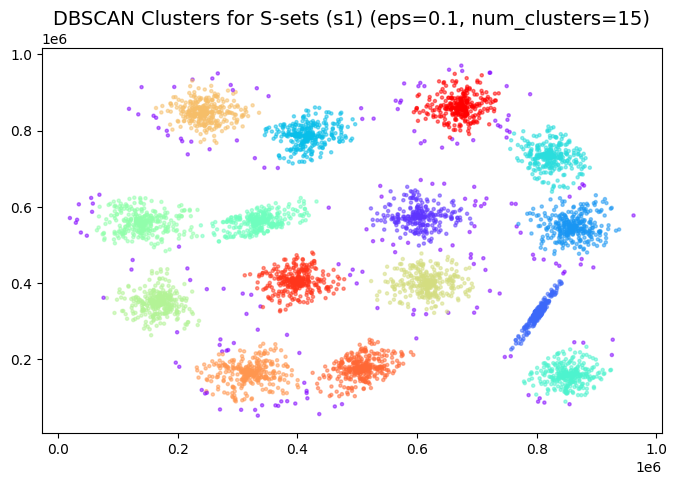


--- Processing DBSCAN for Birch-set data set ---
eps=0.03, min_samples=10, silhouette=-0.6808, clusters=14, noise=1541

Optimal parameters for Birch-set based on Silhouette: eps=0.03, min_samples=10, num_clusters=14


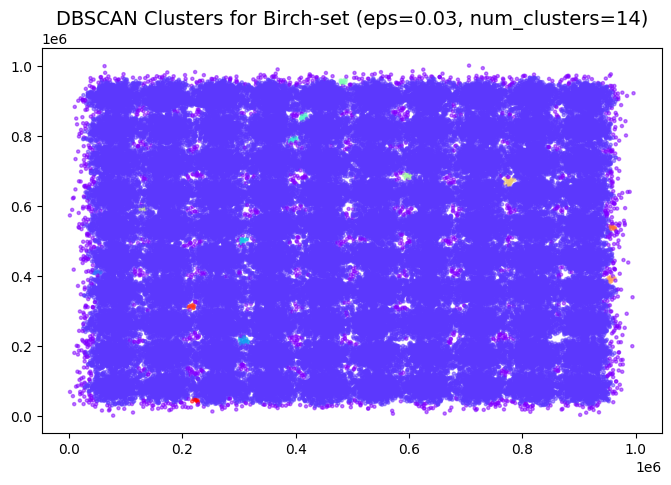


--- Processing DBSCAN for Nested-datasets (n1) data set ---
eps=0.1, min_samples=4, silhouette=-0.2783, clusters=18, noise=284
eps=0.1, min_samples=7, silhouette=0.0032, clusters=12, noise=544
eps=0.1, min_samples=10, silhouette=0.0025, clusters=14, noise=735
eps=0.14444444444444446, min_samples=4, silhouette=0.0176, clusters=10, noise=91
eps=0.14444444444444446, min_samples=7, silhouette=0.0851, clusters=7, noise=211
eps=0.14444444444444446, min_samples=10, silhouette=0.3140, clusters=5, noise=336
eps=0.18888888888888888, min_samples=4, silhouette=-0.2345, clusters=4, noise=56
eps=0.18888888888888888, min_samples=7, silhouette=0.5333, clusters=2, noise=96
eps=0.18888888888888888, min_samples=10, silhouette=0.5118, clusters=2, noise=152
eps=0.23333333333333334, min_samples=7, silhouette=0.2605, clusters=2, noise=47
eps=0.23333333333333334, min_samples=10, silhouette=0.5367, clusters=2, noise=75
eps=0.2777777777777778, min_samples=4, silhouette=0.0991, clusters=2, noise=21
eps=0.322222

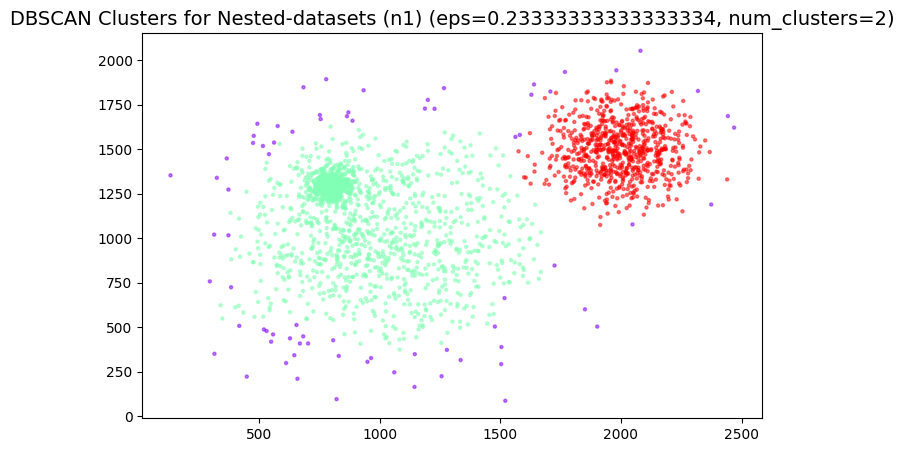

In [23]:
from sklearn.cluster import DBSCAN

def compute_dbscan(df, eps_values, min_samples_values, title=""):
    print(f"\n--- Processing DBSCAN for {title} data set ---")

    best_eps = None
    best_min_samples = None
    best_labels = None
    max_silhouette = -1
    best_clusters = 0

    my_scaler = StandardScaler()
    scaled_features = my_scaler.fit_transform(df)

    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(scaled_features)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)

            if n_clusters > 1:
                score = silhouette_score(scaled_features, labels)
                print(f"eps={eps}, min_samples={min_samples}, silhouette={score:.4f}, clusters={n_clusters}, noise={n_noise}")

                if score > max_silhouette:
                    max_silhouette = score
                    best_eps = eps
                    best_min_samples = min_samples
                    best_labels = labels
                    best_clusters = n_clusters

    print(f"\nOptimal parameters for {title} based on Silhouette: eps={best_eps}, min_samples={best_min_samples}, num_clusters={best_clusters}")

    plt.figure(figsize=(8, 5))
    plt.title(f"DBSCAN Clusters for {title} (eps={best_eps}, num_clusters={best_clusters})", fontsize=14)
    plt.scatter(df[:, 0], df[:, 1], c=best_labels, cmap='rainbow', alpha=0.5, s=5)
    plt.show()

compute_dbscan(loaded_data['s1'].values, np.linspace(0.1, 0.2, 5), min_samples_values=[4, 7, 10], title="S-sets (s1)")
compute_dbscan(loaded_data['birch1'].values, [0.03, 0.06, 0.09], [10], "Birch-set")
compute_dbscan(loaded_data['n1'].values, np.linspace(0.1, 0.5, 10), min_samples_values=[4, 7, 10], title="Nested-datasets (n1)")

DBSCAN performs well on all datasets, but the results are most interesting for the nested dataset. After implementing DBSCAN, it becomes clear that this method is a great fit when clusters are not “round” and can have irregular shapes.

`Nested-set`: DBSCAN works best here because it groups points by density connectivity and can recover nested structures.

`S-set`: The result is correct, but DBSCAN is sensitive to the choice of `eps` and `min_samples` which means that a small changes can noticeably change how much becomes noise.

`Birch-set`: Due to the large size and density of the dataset, tuning DBSCAN parameters can take a significant amount of time.

### Clustering summary

`K-Means`: Fast and easy to tune (choose `k`). Best for large datasets with well-separated, spherical clusters. Does not handle noise explicitly and performs poorly on non-convex shapes (e.g., nested/rings).

`DBSCAN`: Finds arbitrarily shaped clusters and explicitly labels noise. The best use case is when we expect irregular shapes or noise. DBSCAN is sensitive to `eps`/`min_samples` and can be slow to tune on very large, dense datasets.

`Agglomerative clustering`: Builds a hierarchy of merges (useful when we want a multi-level view of structure). Can work better than K-Means on some non-spherical shapes depending on linkage, but is typically more expensive for large datasets and does not naturally label noise like DBSCAN.